In [1]:
from ultralytics import YOLO
from roboflow import Roboflow
import os
from PIL import Image
from IPython.display import display

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="JGW2IWec7WCTsiHssTTH")
project = rf.workspace("eman-fatima-e1ncy").project("construction-equipment-vwgkt-sddhi")
version = project.version(1)
dataset = version.download("yolov8")


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to construction-equipment-1 in yolov8:: 100%|██████████| 483/483 [00:02<00:00, 182.37it/s]


In [3]:
dataset_path = dataset.location

for root, dirs, files in os.walk(dataset_path):
    print(root)

C:\Users\Localws\construction-equipment-1
C:\Users\Localws\construction-equipment-1\test
C:\Users\Localws\construction-equipment-1\test\images
C:\Users\Localws\construction-equipment-1\test\labels
C:\Users\Localws\construction-equipment-1\train
C:\Users\Localws\construction-equipment-1\train\images
C:\Users\Localws\construction-equipment-1\train\labels
C:\Users\Localws\construction-equipment-1\valid
C:\Users\Localws\construction-equipment-1\valid\images
C:\Users\Localws\construction-equipment-1\valid\labels


In [4]:
yaml_path = os.path.join(dataset_path, "data.yaml")

with open(yaml_path, "r") as file:
    print(file.read())

names:
- C_E
nc: 1
roboflow:
  license: CC BY 4.0
  project: construction-equipment-vwgkt-sddhi
  url: https://universe.roboflow.com/eman-fatima-e1ncy/construction-equipment-vwgkt-sddhi/dataset/1
  version: 1
  workspace: eman-fatima-e1ncy
test: ../test/images
train: ../train/images
val: ../valid/images



In [5]:
model = YOLO("yolov8n.pt")

In [6]:
results = model.train(
    data=yaml_path,
    epochs=5,
    imgsz=320,
    batch=4,
    workers=0,
    project="Construction_Project",
    name="Experiment1"
)

New https://pypi.org/project/ultralytics/8.4.114 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.95  Python-3.13.7 torch-2.13.0+cpu CPU (Intel Core i5-5300U 2.30GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Localws\construction-equipment-1\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9

In [14]:
import os

experiment_path = "runs/detect/Construction_Project/Experiment1"

print("Files in Experiment Folder:\n")

for file in os.listdir(experiment_path):
    print(file)

Files in Experiment Folder:

args.yaml
BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


BoxF1_curve.png


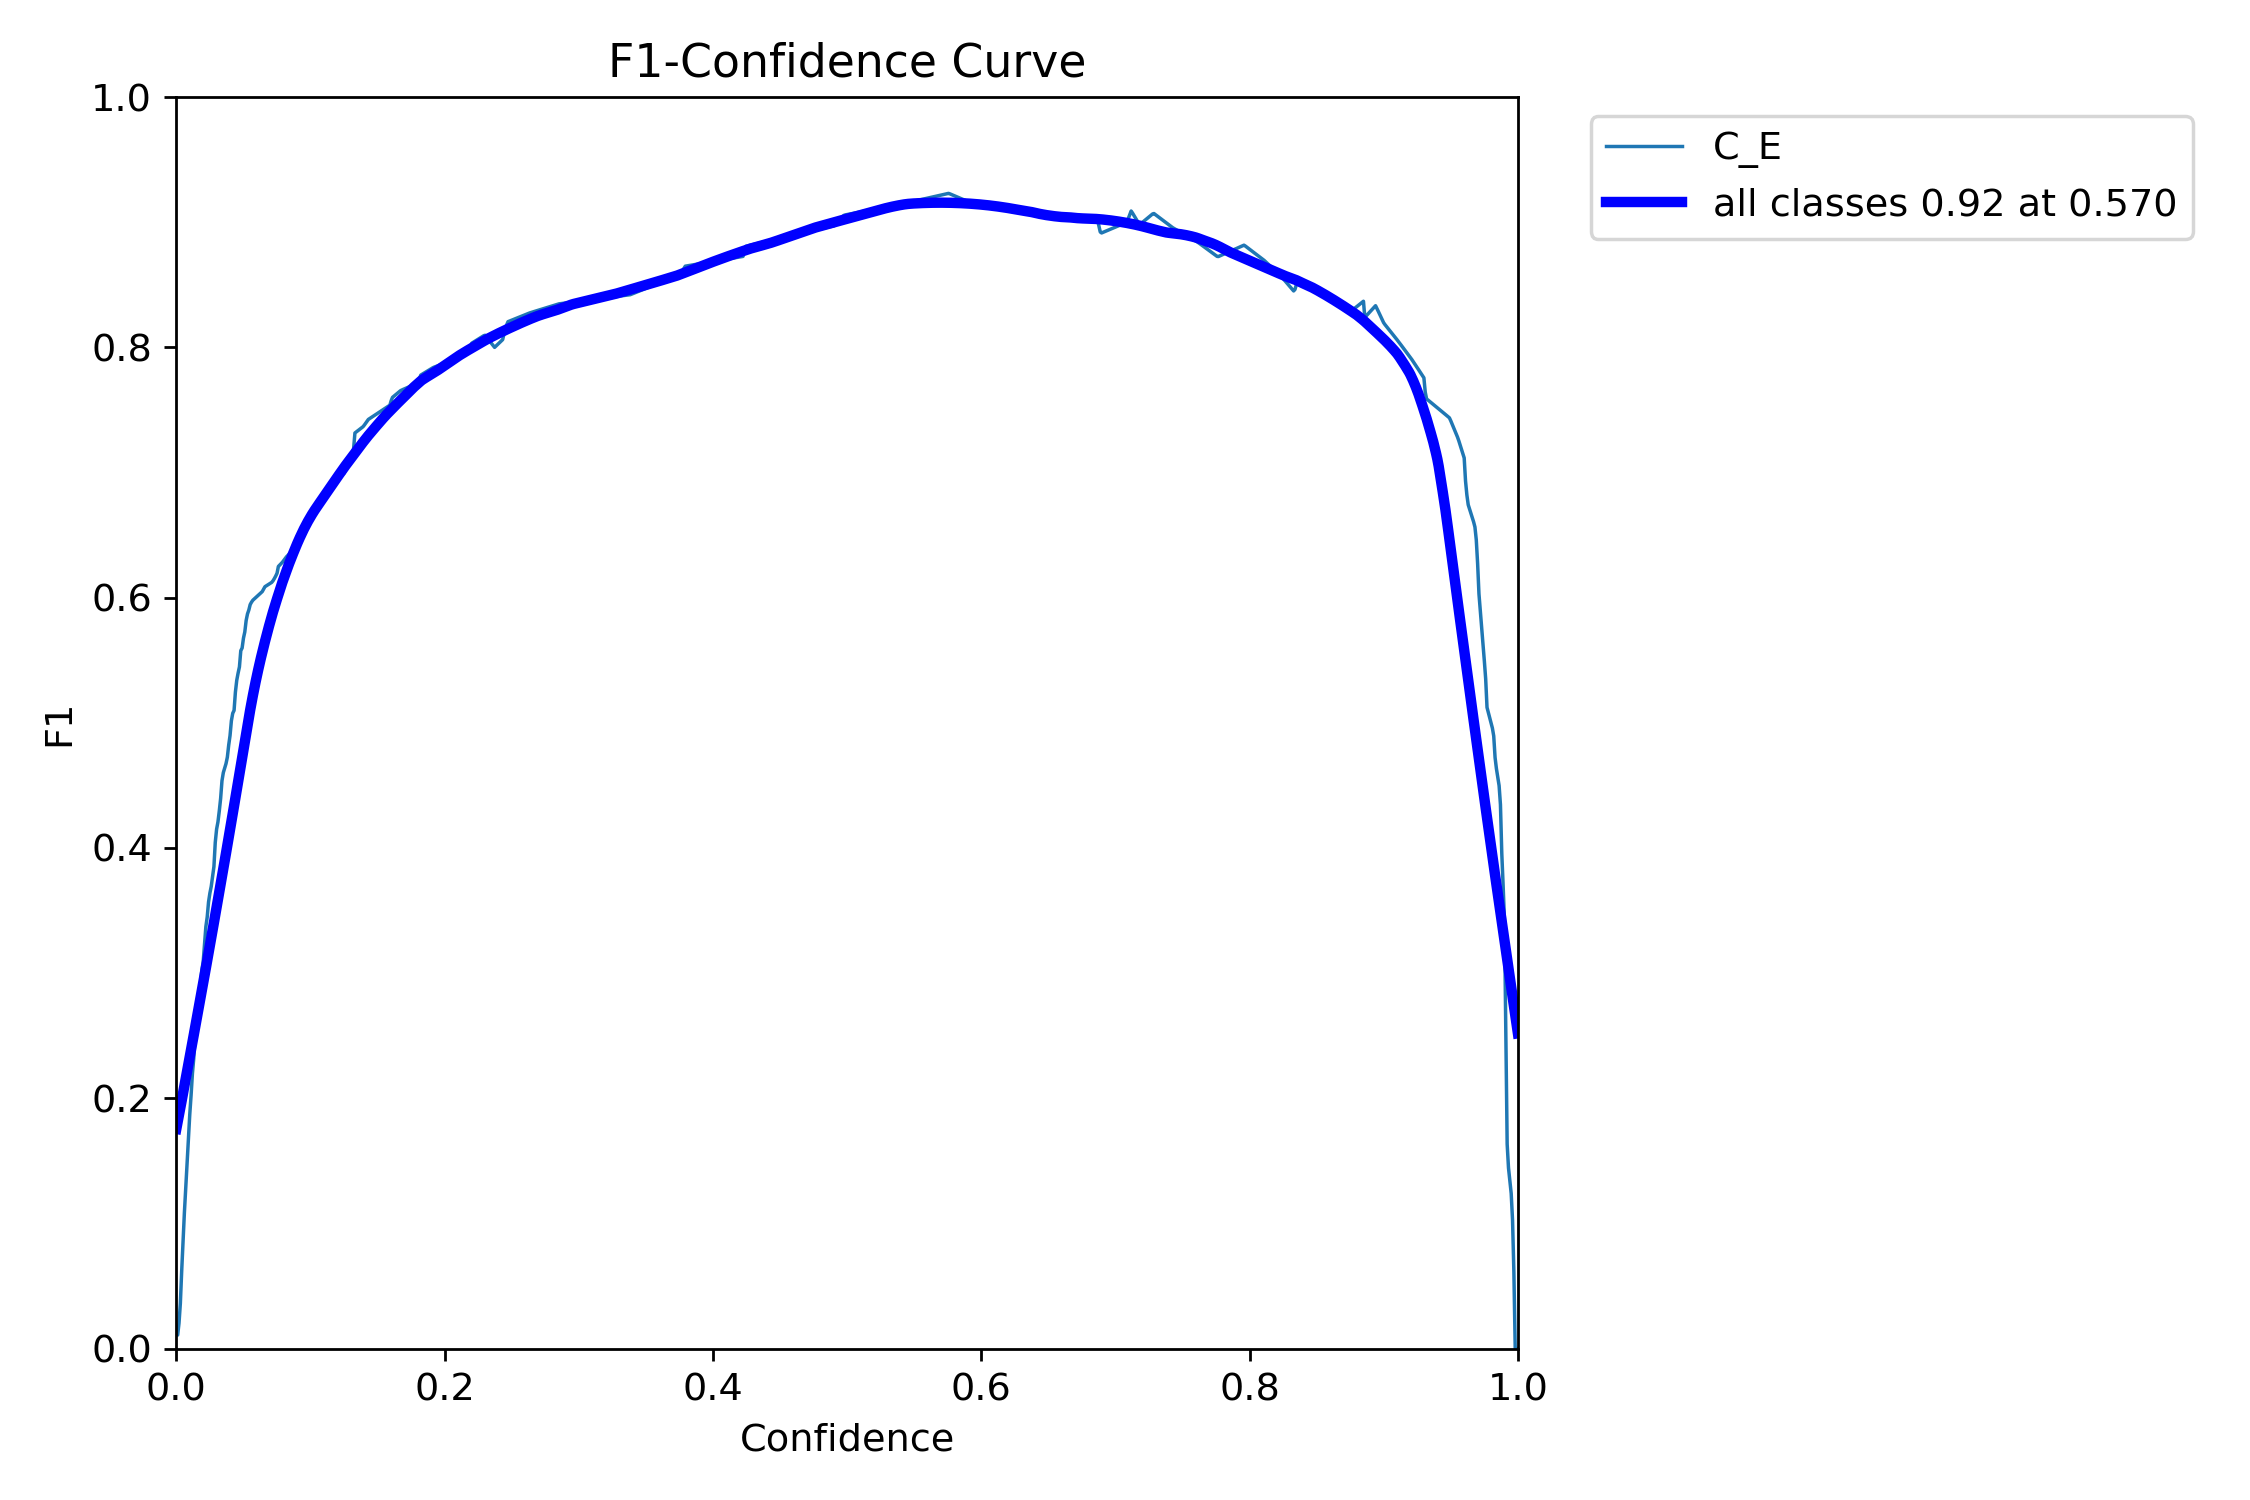

BoxPR_curve.png


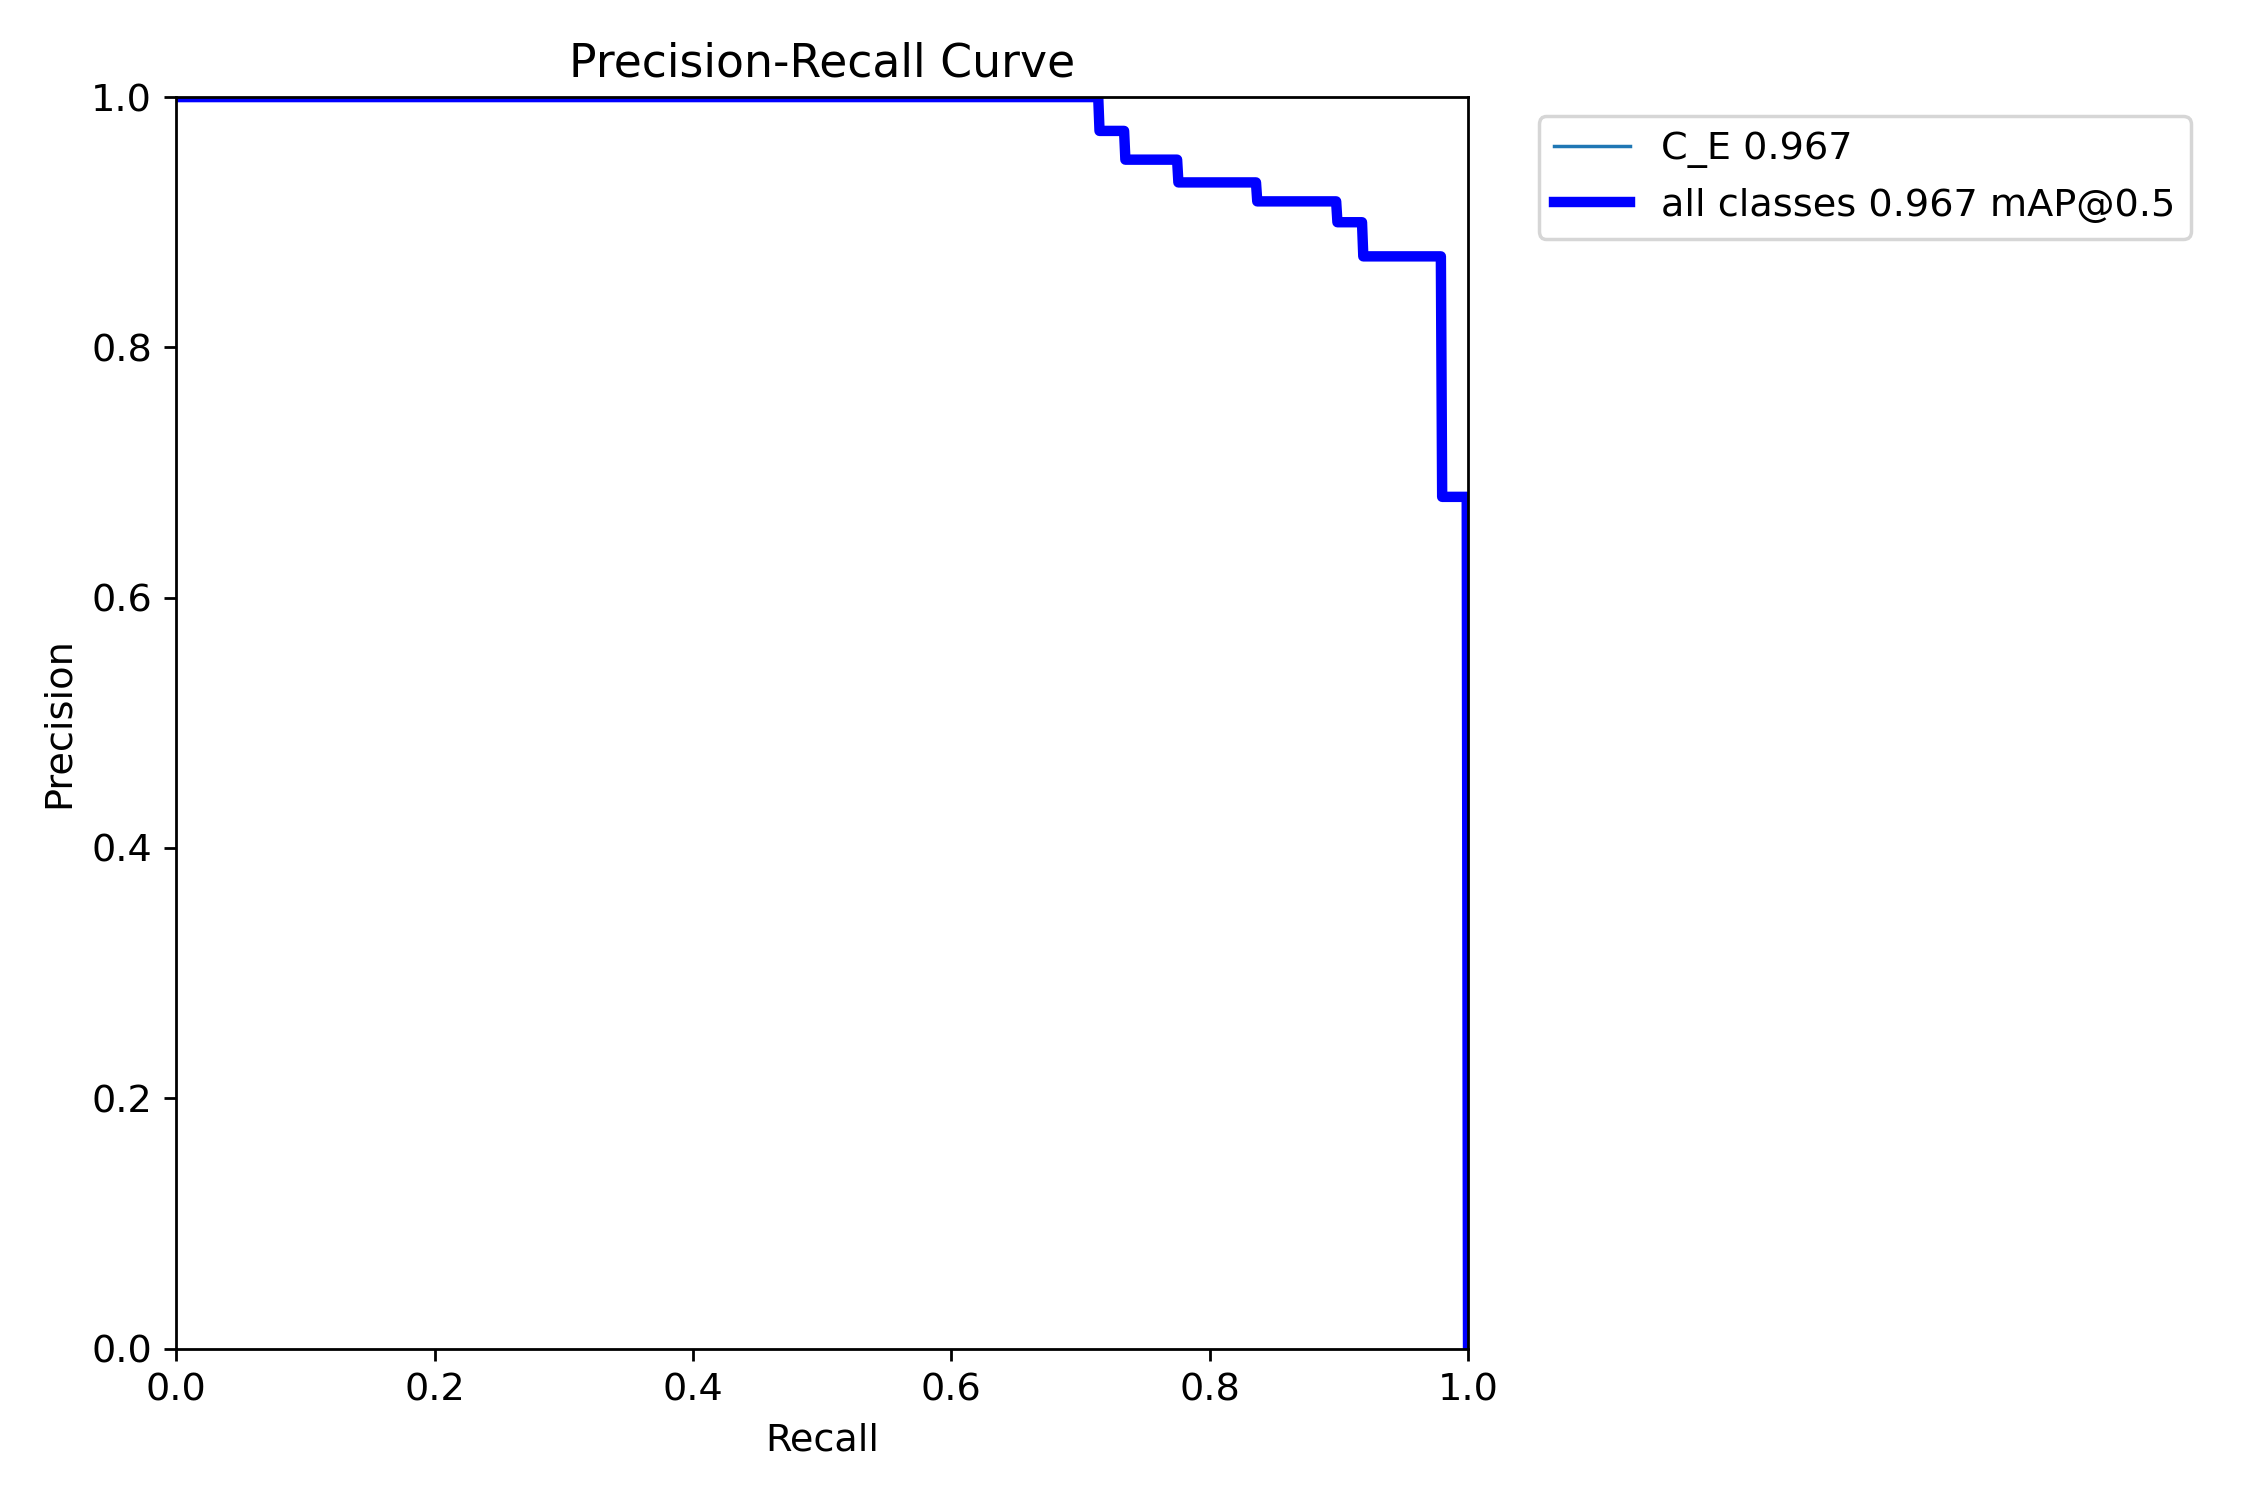

BoxP_curve.png


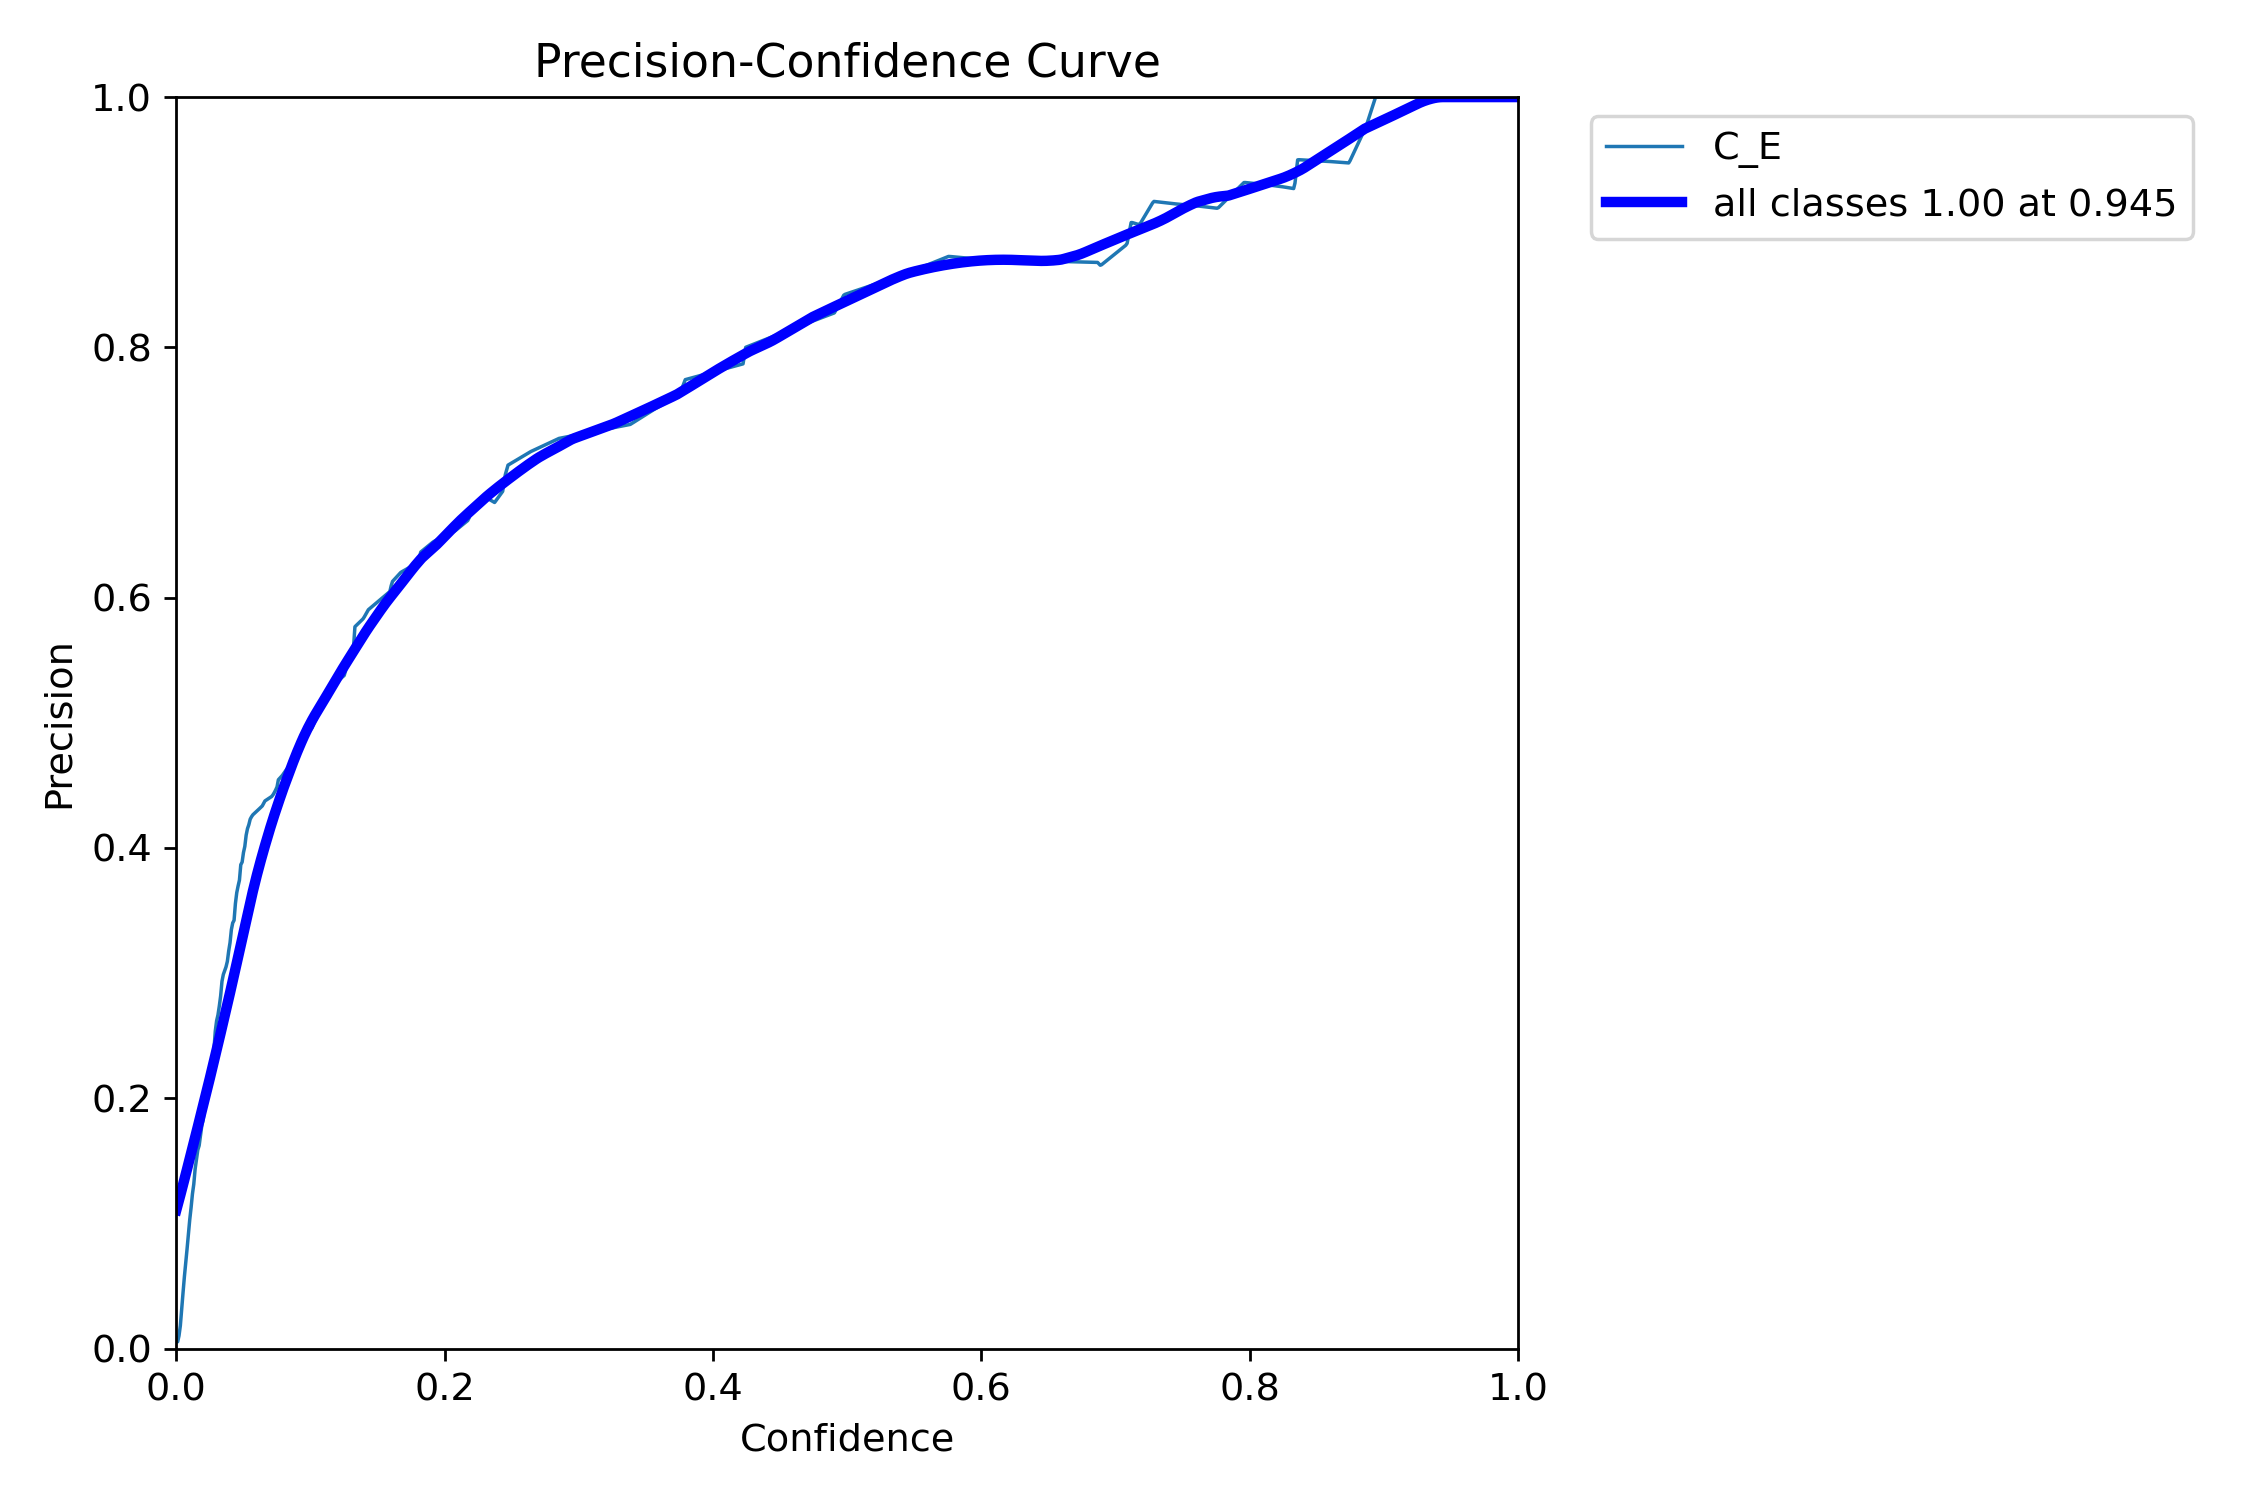

BoxR_curve.png


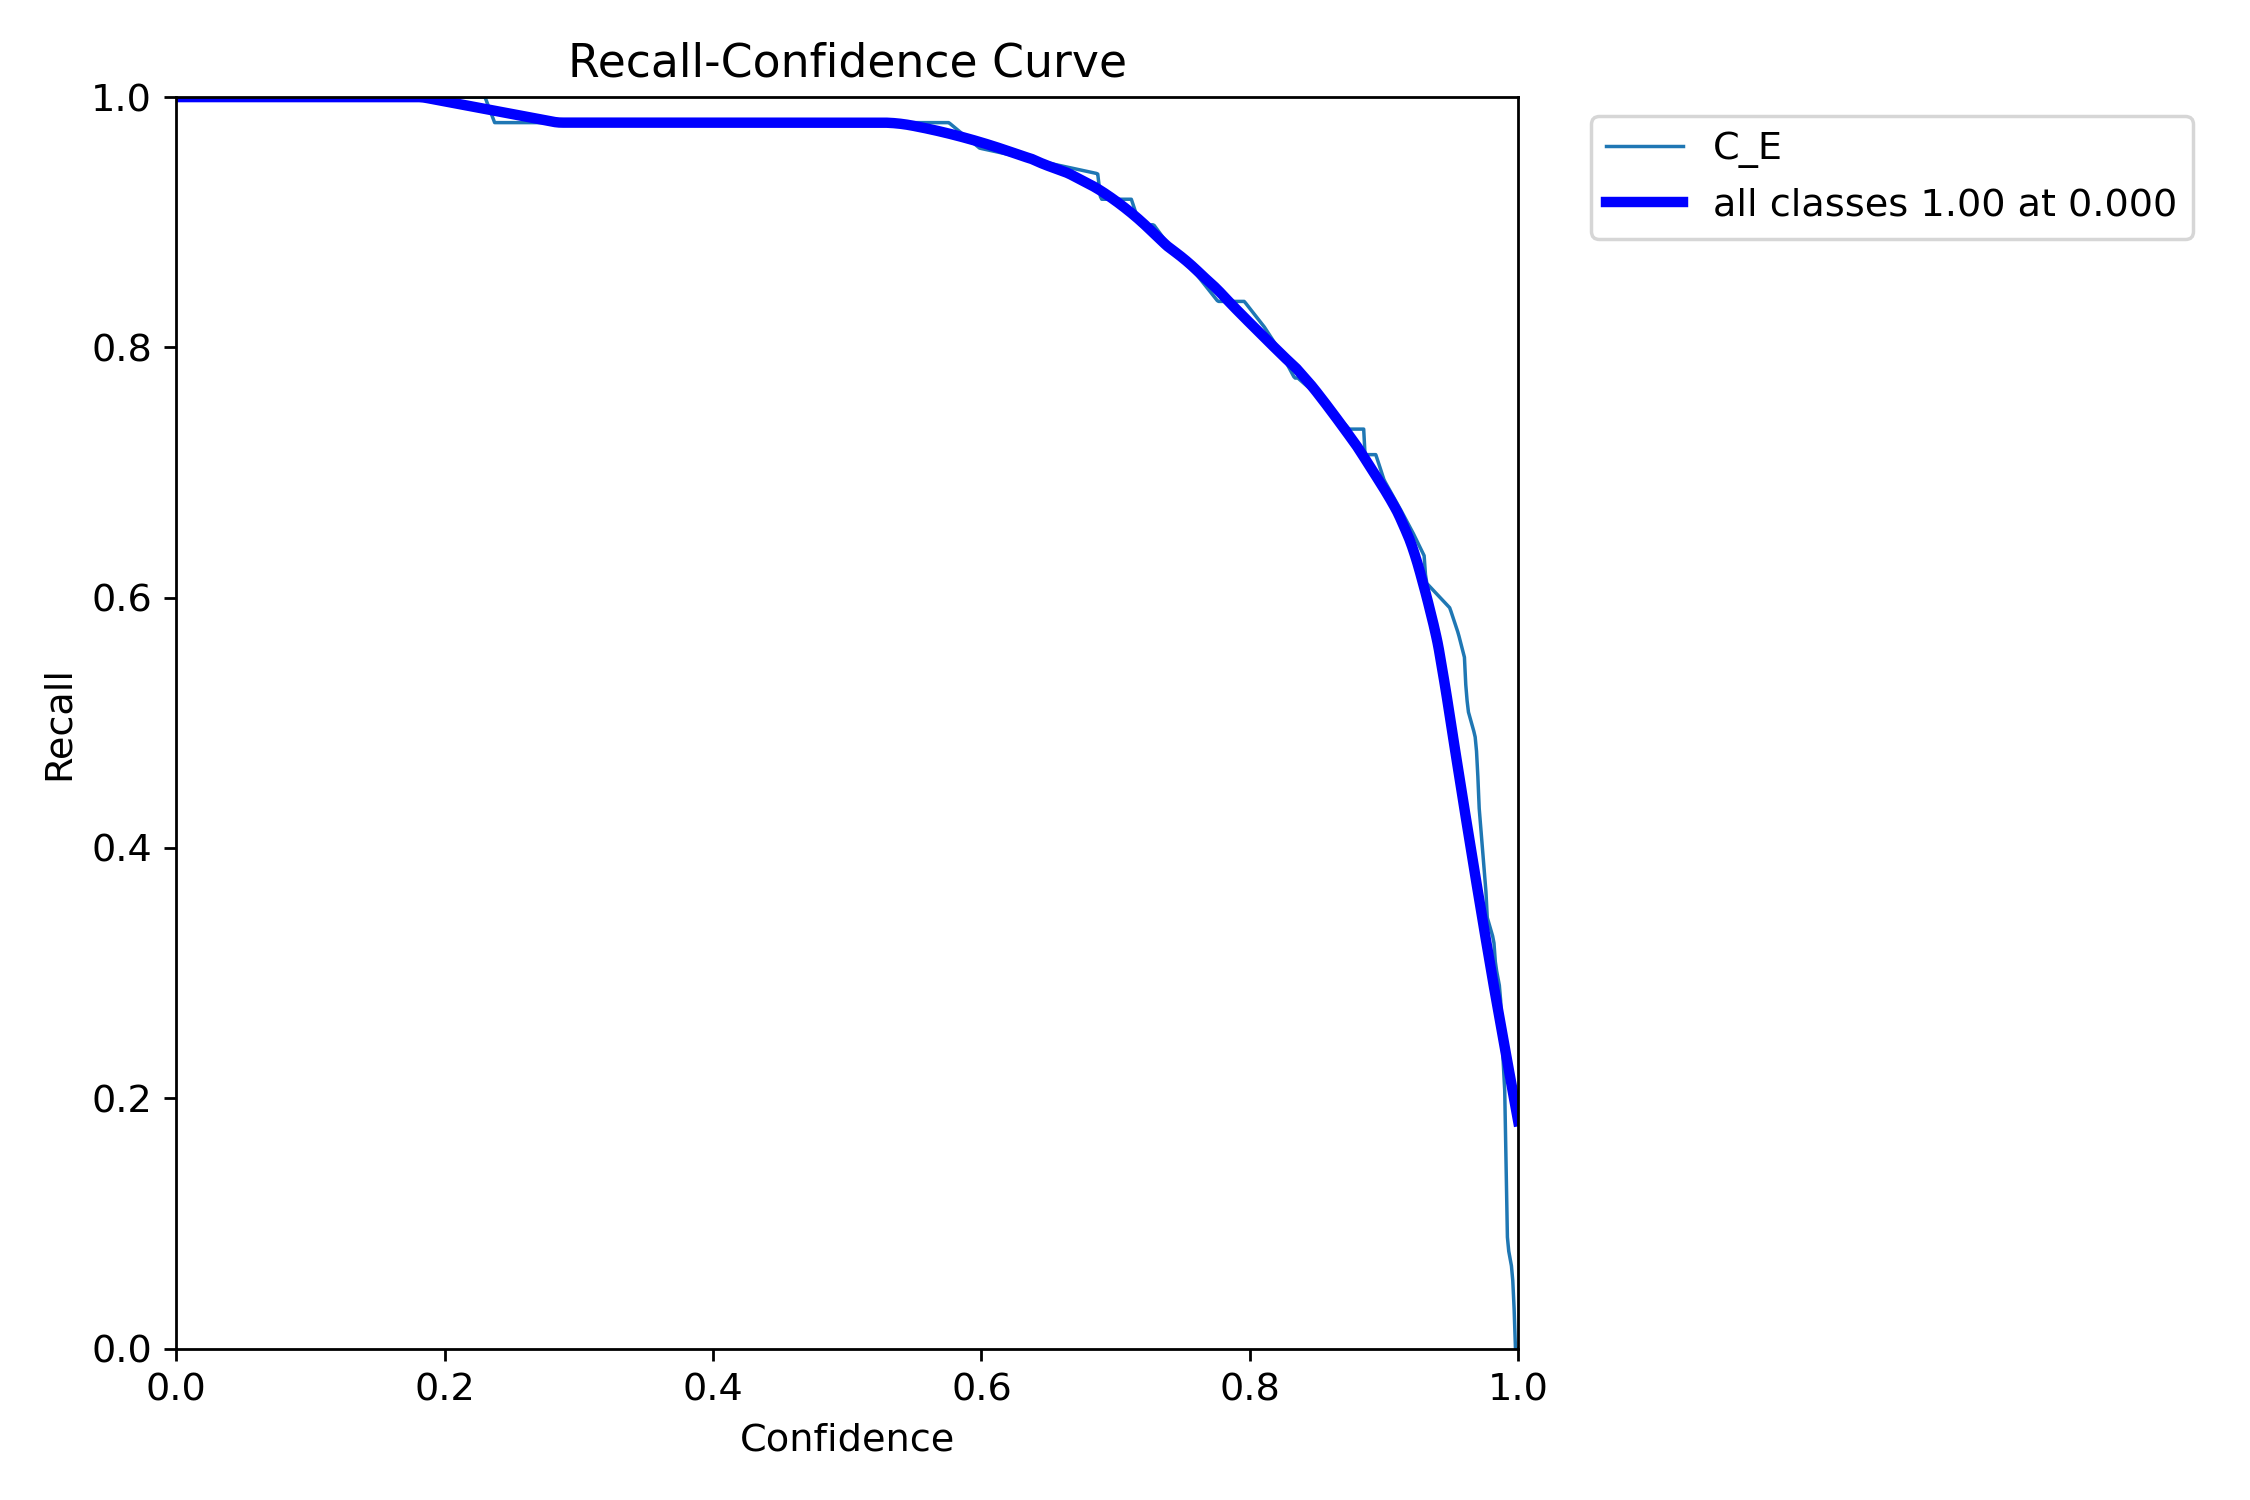

confusion_matrix.png


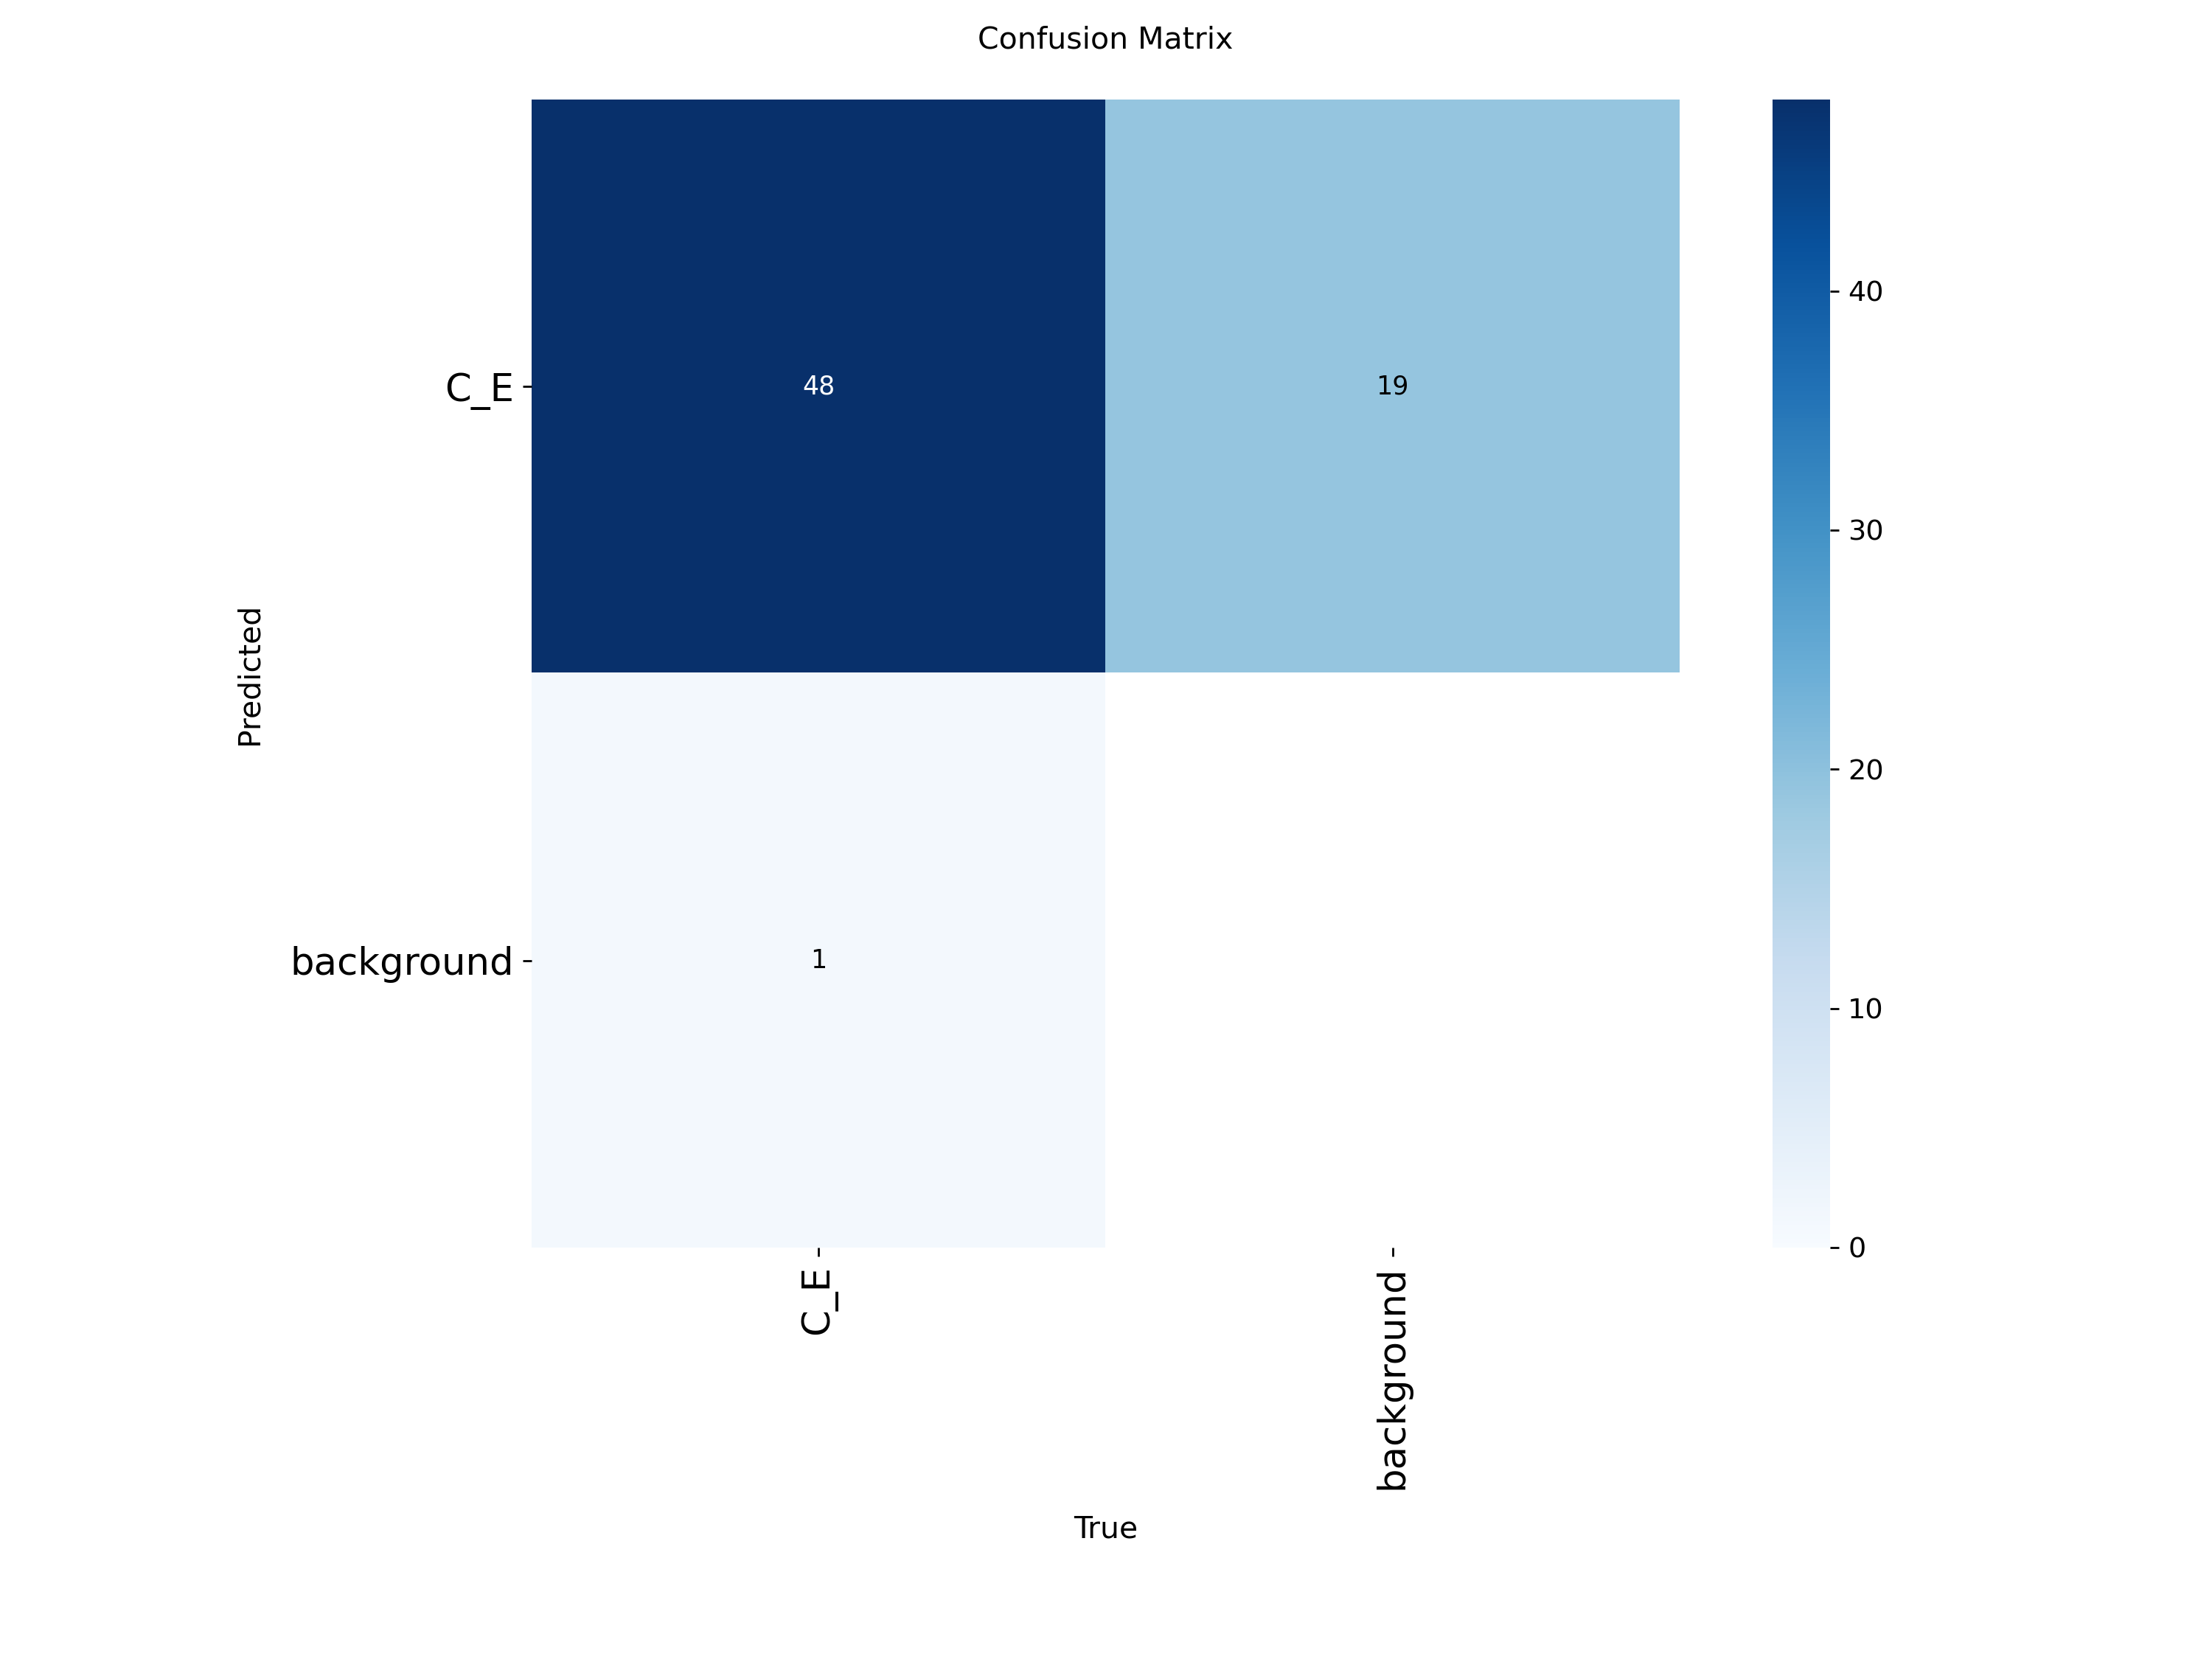

confusion_matrix_normalized.png


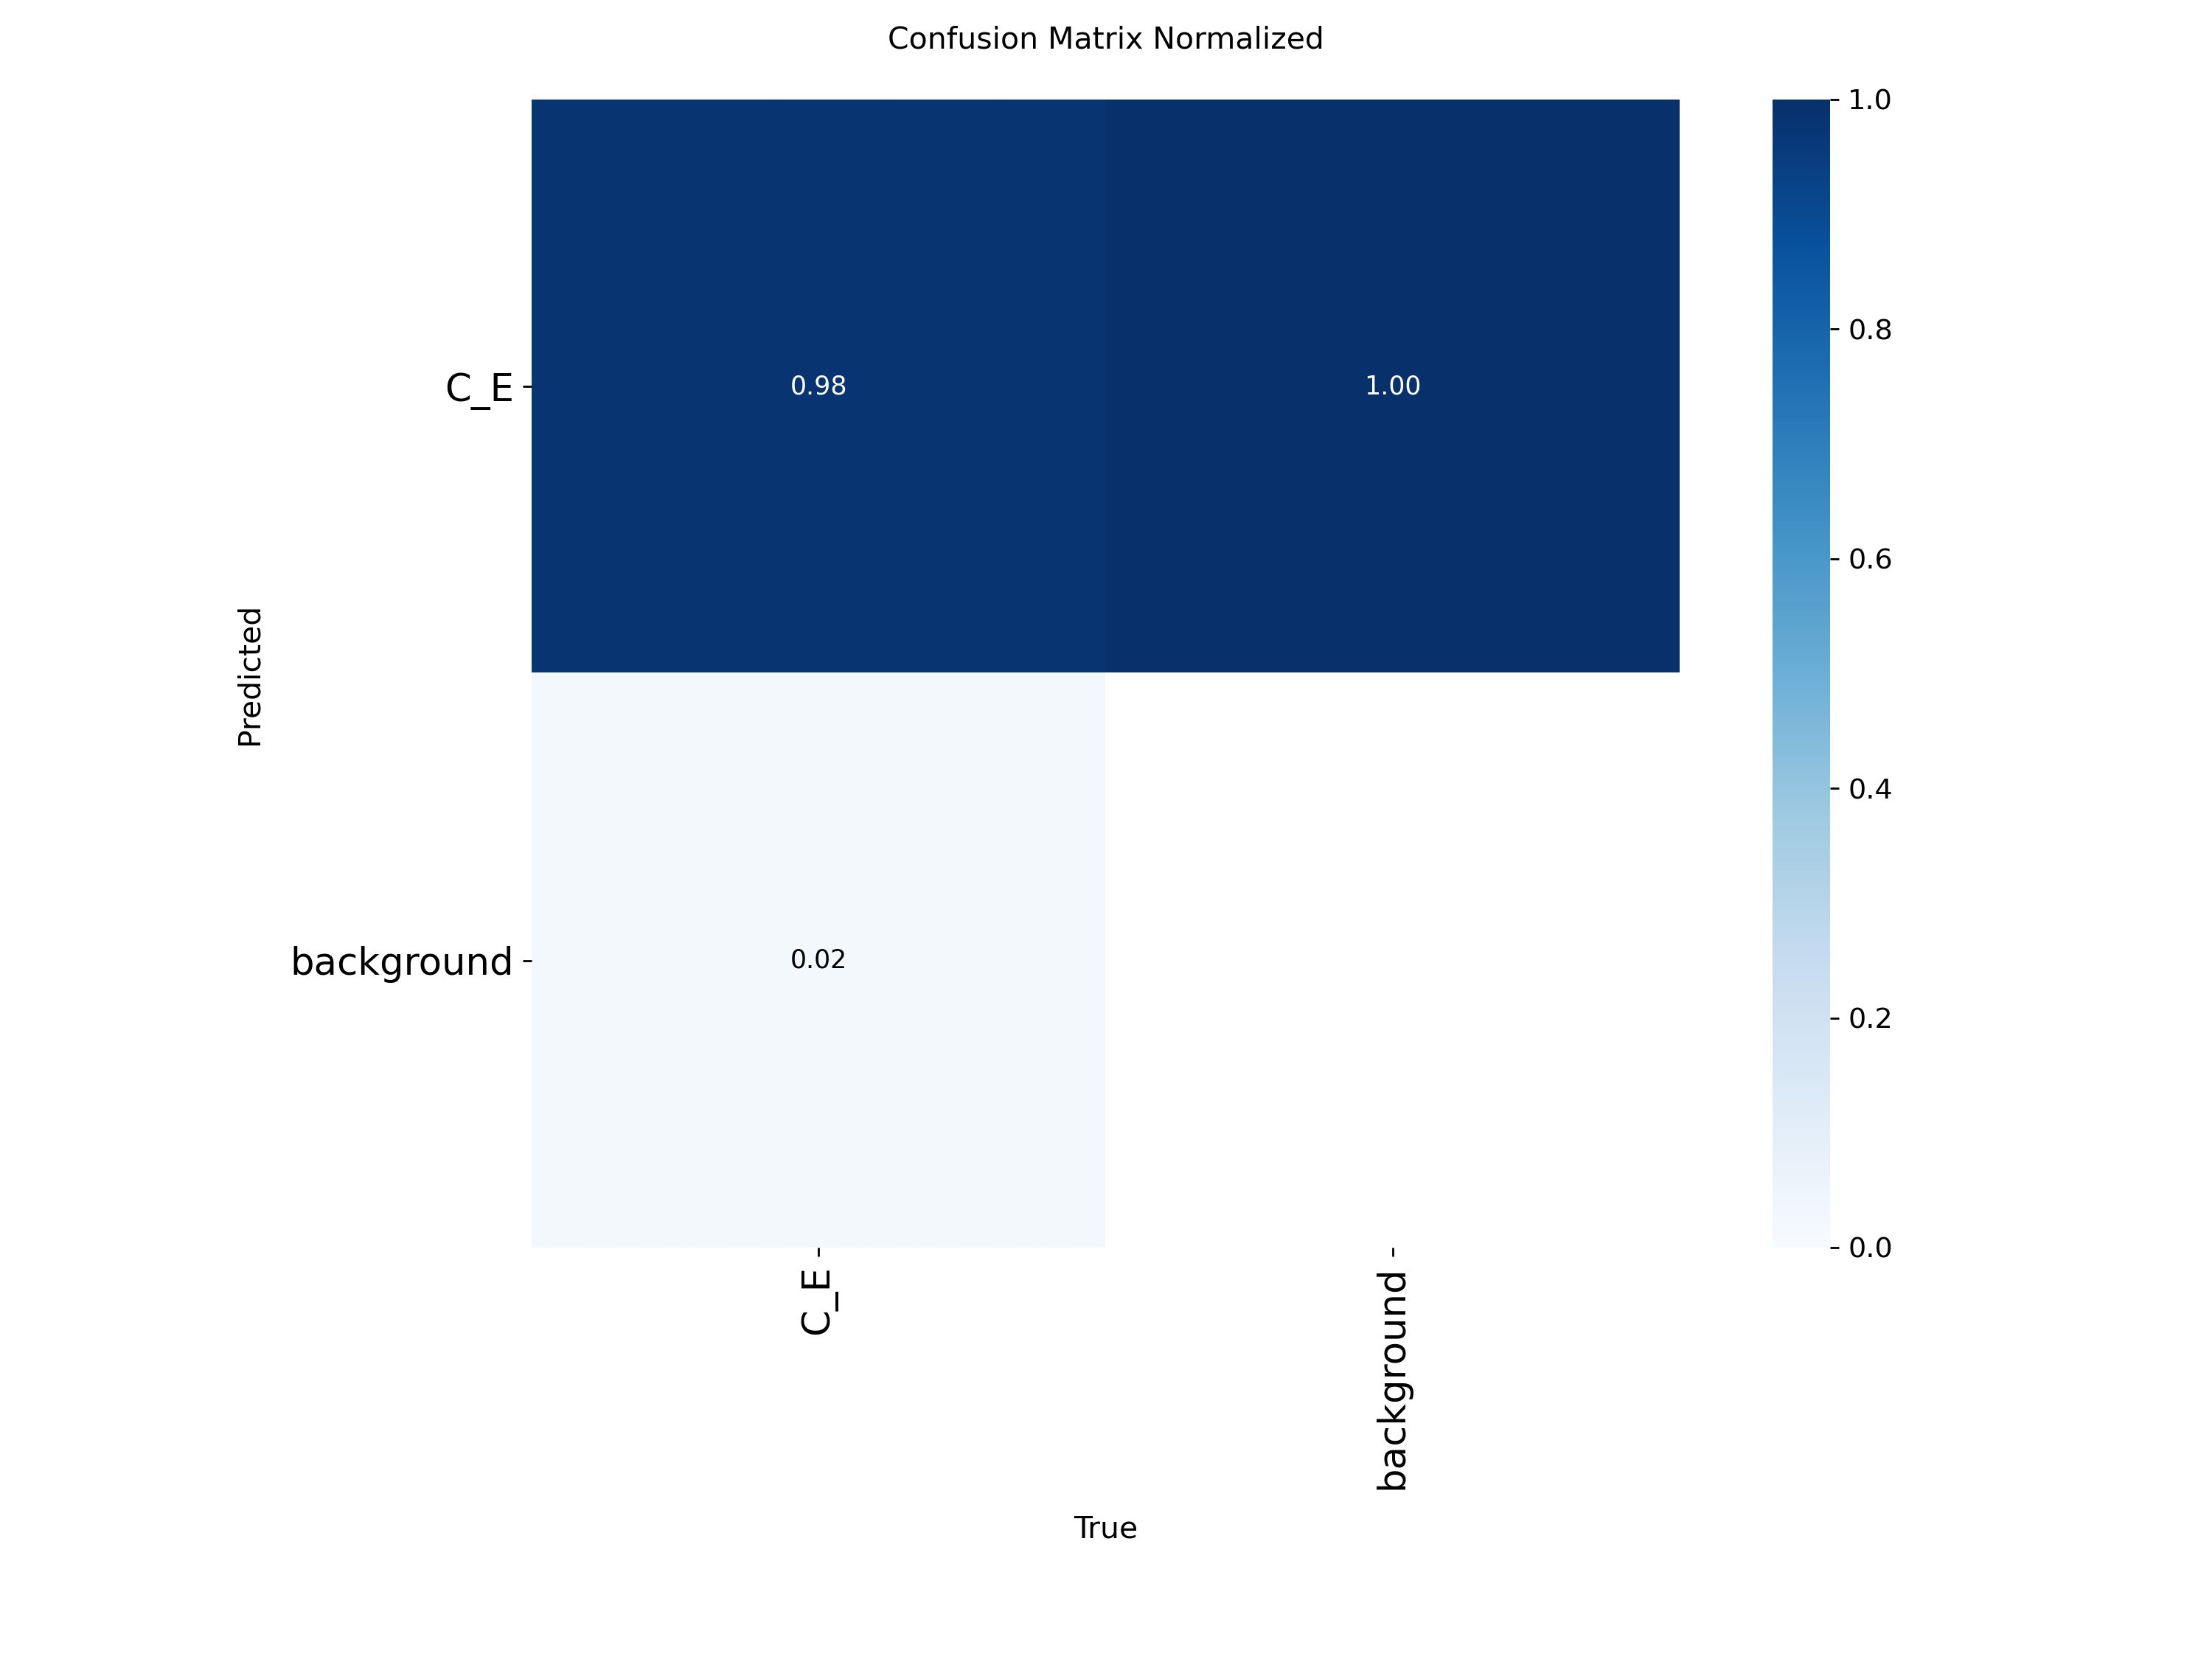

results.png


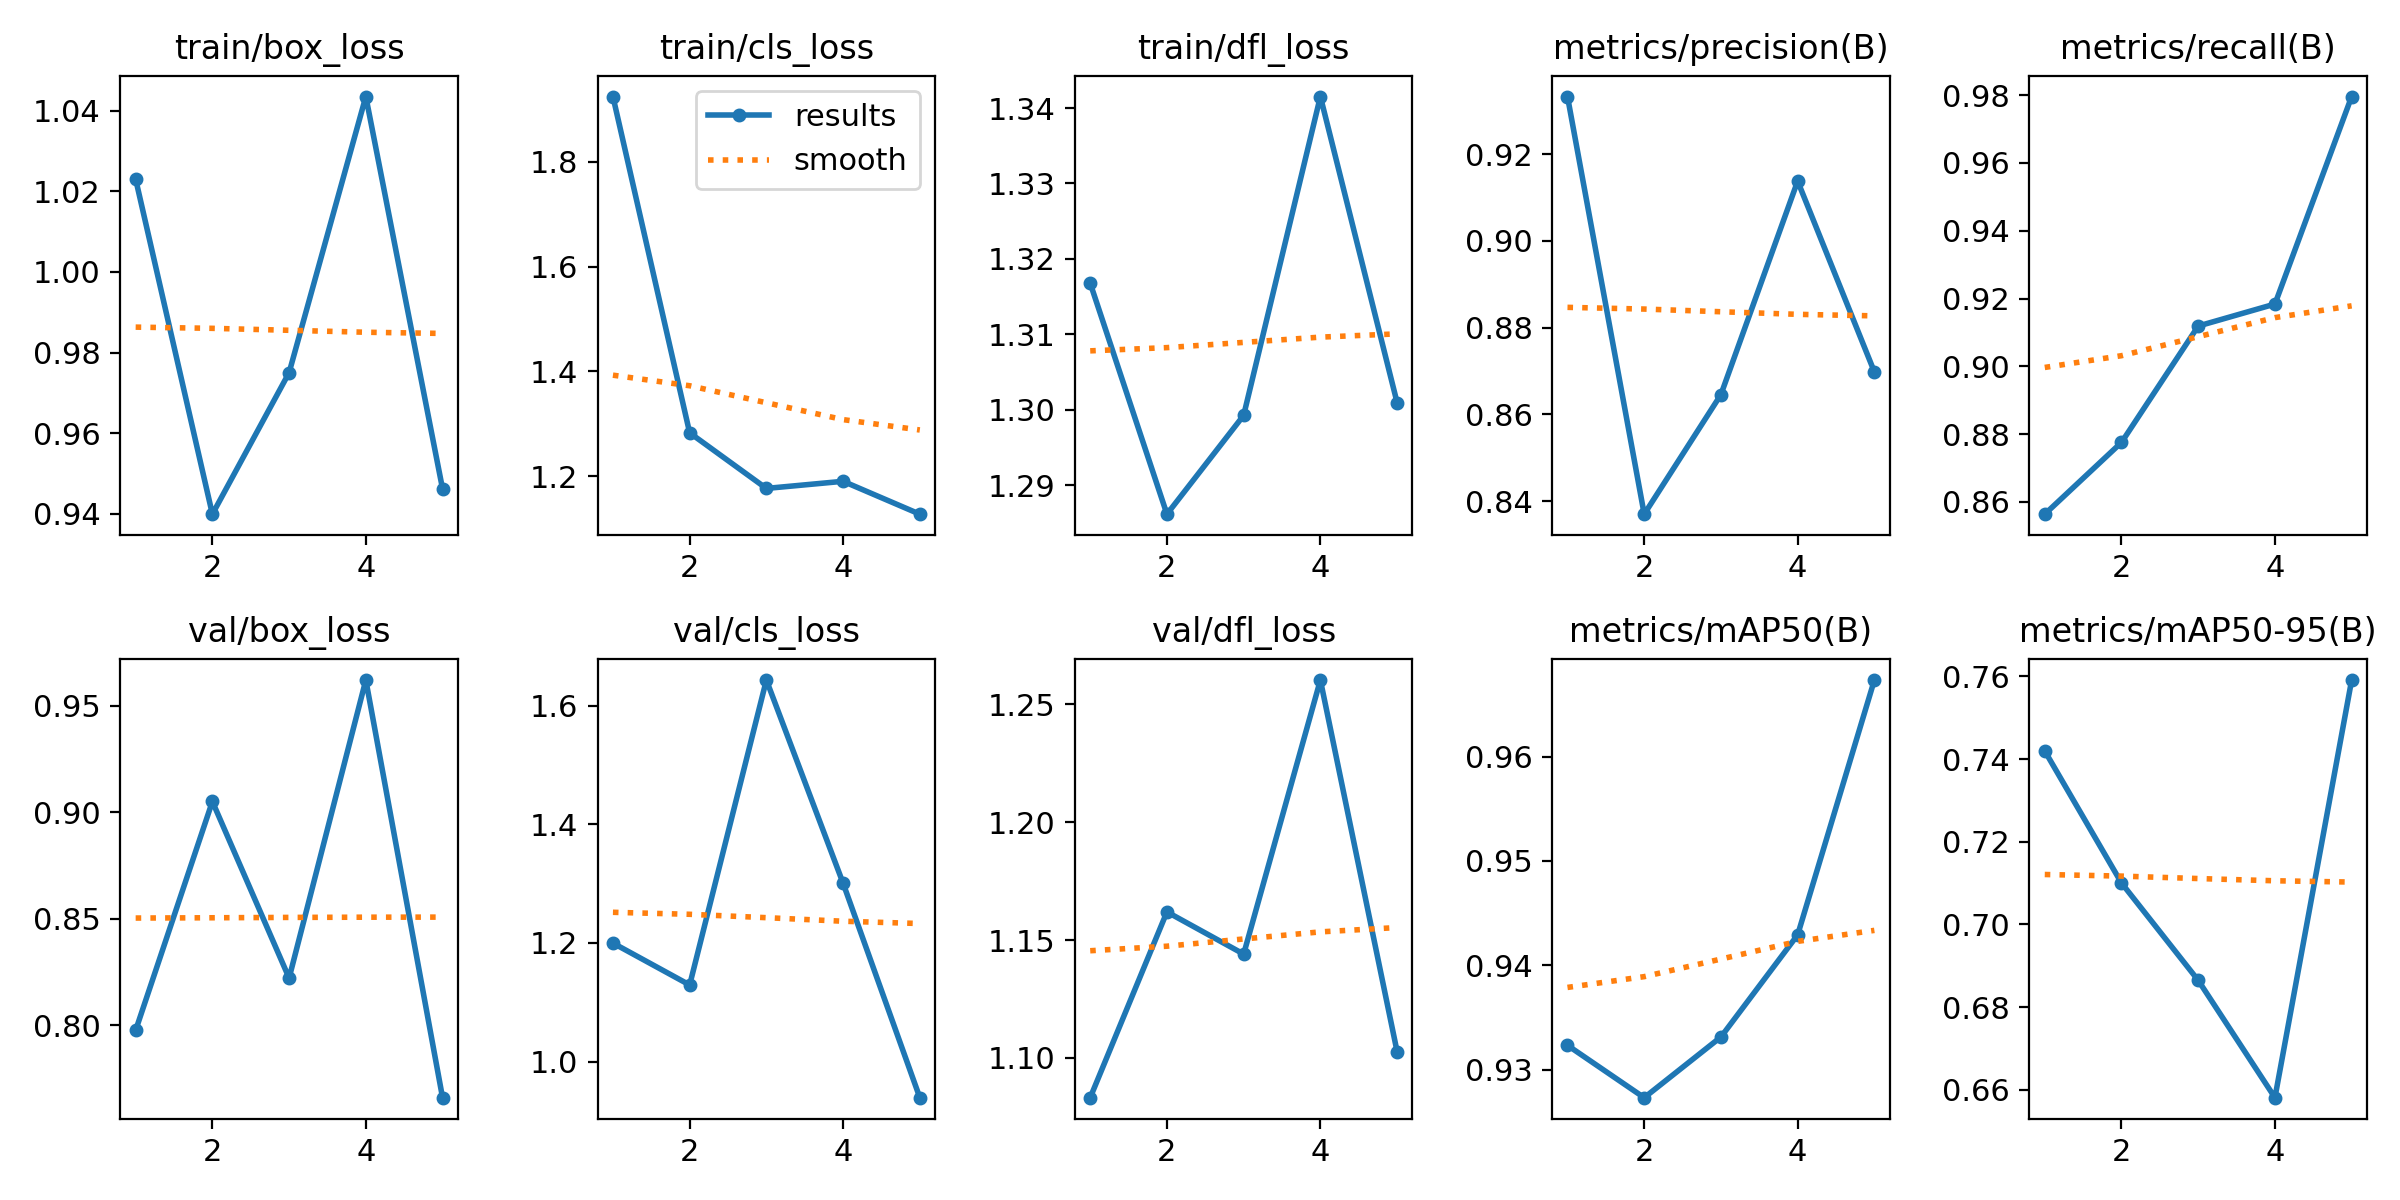

In [15]:
from PIL import Image
from IPython.display import display
import os

experiment_path = "runs/detect/Construction_Project/Experiment1"

for file in os.listdir(experiment_path):
    if file.endswith(".png"):
        print(file)
        display(Image.open(os.path.join(experiment_path, file)))

In [16]:
metrics = model.val()

Ultralytics 8.4.95  Python-3.13.7 torch-2.13.0+cpu CPU (Intel Core i5-5300U 2.30GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
WARNING val: Slow image access detected (ping: 0.80.5 ms, read: 47.316.3 MB/s, size: 60.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning C:\Users\Localws\construction-equipment-1\valid\labels.cache... 49 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 49/49 3.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 4.7s/it 18.8s8.9s0s
                   all         49         49       0.87       0.98      0.967      0.761
Speed: 5.2ms preprocess, 287.8ms inference, 0.0ms loss, 9.1ms postprocess per image
Results saved to C:\Users\Localws\runs\detect\val-2


In [17]:
print("Precision :", metrics.box.mp)
print("Recall    :", metrics.box.mr)
print("mAP@50    :", metrics.box.map50)
print("mAP50-95  :", metrics.box.map)

Precision : 0.870081615207536
Recall    : 0.9795918367346939
mAP@50    : 0.9673432978432976
mAP50-95  : 0.760730184035445


In [19]:
from ultralytics import YOLO

best_model = YOLO("runs/detect/Construction_Project/Experiment1/weights/best.pt")

In [20]:
import os

test_folder = os.path.join(dataset.location, "test", "images")

test_images = sorted(os.listdir(test_folder))

print("Total Test Images:", len(test_images))

Total Test Images: 21


In [21]:
for image in test_images[:10]:

    image_path = os.path.join(test_folder, image)

    best_model.predict(
        source=image_path,
        conf=0.25,
        save=True,
        project="Predictions",
        name="Construction_Result"
    )

print("Inference Completed Successfully!")


image 1/1 C:\Users\Localws\construction-equipment-1\test\images\KakaoTalk_20240402_183303114_01_jpg.rf.72241a56814d05ea1fdbf9d024884c71.jpg: 224x320 2 C_Es, 419.1ms
Speed: 12.5ms preprocess, 419.1ms inference, 5.7ms postprocess per image at shape (1, 3, 224, 320)
Results saved to C:\Users\Localws\runs\detect\Predictions\Construction_Result

image 1/1 C:\Users\Localws\construction-equipment-1\test\images\KakaoTalk_20240402_183303114_03_jpg.rf.b82bc5963d2f7bd9ab2bde9029697f85.jpg: 256x320 1 C_E, 292.8ms
Speed: 6.1ms preprocess, 292.8ms inference, 4.8ms postprocess per image at shape (1, 3, 256, 320)
Results saved to C:\Users\Localws\runs\detect\Predictions\Construction_Result-2

image 1/1 C:\Users\Localws\construction-equipment-1\test\images\KakaoTalk_20240402_183303114_05_png.rf.4f1e2109082d742355f1a93e2738eab5.jpg: 320x256 1 C_E, 264.9ms
Speed: 4.8ms preprocess, 264.9ms inference, 2.7ms postprocess per image at shape (1, 3, 320, 256)
Results saved to C:\Users\Localws\runs\detect\Predi

Latest Prediction Folder: Construction_Result-9
OIP-14-_jpg.rf.fe8b25f29de19b7b355f5c8510454069.jpg


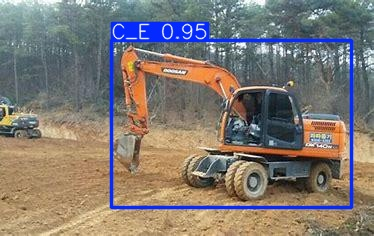

In [26]:
from PIL import Image
from IPython.display import display
import os

base_folder = "runs/detect/Predictions"

folders = sorted(os.listdir(base_folder))
latest_folder = folders[-1]

prediction_folder = os.path.join(base_folder, latest_folder)

print("Latest Prediction Folder:", latest_folder)

prediction_images = sorted(os.listdir(prediction_folder))

for img in prediction_images:
    print(img)
    display(Image.open(os.path.join(prediction_folder, img)))

In [28]:
import os

base_folder = "runs/detect/Predictions"

folders = sorted(os.listdir(base_folder))
latest_folder = folders[-1]

prediction_folder = os.path.join(base_folder, latest_folder)

print("Latest Prediction Folder:", latest_folder)
print("\nSaved Prediction Images:\n")

for img in sorted(os.listdir(prediction_folder)):
    print(img)

Latest Prediction Folder: Construction_Result-9

Saved Prediction Images:

OIP-14-_jpg.rf.fe8b25f29de19b7b355f5c8510454069.jpg
